In [1]:
#import packages and dataset
from datasets import load_dataset
import pandas as pd
import numpy as np

ds = load_dataset("howardzhao3/train24", "default", split="train")

print(ds)
print(ds[0])

/Users/zhaohan/Python_Projects/MDA_Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description'],
    num_rows: 2419098
})
{'site_id': 1, 'direction': 'in', 'year': 2024, 'month': 1, 'day': 1, 'hour': 0, 'lat_x': 50.916183, 'lon': 4.456122, 'count': 0.0, 'obs_count': 4, 'time': '2024-01-01 00:00:00', 'temperature_2m': 7.85, 'apparent_temperature': 0.9682741, 'relative_humidity_2m': 72.43961, 'precipitation': 0.0, 'rain': 0.0, 'snowfall': 0.0, 'wind_speed_10m': 10.104455, 'shortwave_radiation': 0.0, 'direct_normal_irradiance': 0.0, 'sunshine_duration': 0.0, '

In [2]:
df = ds.to_pandas()
print(df.shape)
print(df.columns.tolist())
df.head()

(2419098, 37)
['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description']


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo


In [3]:
#preprocessing
df_2024 = df.copy()
if "year" in df_2024.columns:
    df_2024 = df_2024[df_2024["year"] == 2024].copy()

# Create date column if year/month/day columns exist
if all(col in df_2024.columns for col in ["year", "month", "day"]):
    df_2024["date_dt"] = pd.to_datetime(
        df_2024[["year", "month", "day"]],
        errors="coerce"
    )
else:
    print("No year/month/day columns found. Check your date column manually.")

# Create day-of-week and weekend flag
df_2024["day_of_week"] = df_2024["date_dt"].dt.dayofweek
df_2024["is_weekend_binary"] = df_2024["day_of_week"].isin([5, 6]).astype(int)

# Rush hour flag
if "hour" in df_2024.columns:
    df_2024["is_rush_hour"] = df_2024["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
else:
    print("No hour column found. Rush-hour features will not be correct.")
    df_2024["is_rush_hour"] = 0

# Make sure count is numeric
df_2024["count"] = pd.to_numeric(df_2024["count"], errors="coerce")


In [4]:
print(df_2024.shape)
df_2024.head()

(2419098, 41)


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description,date_dt,day_of_week,is_weekend_binary,is_rush_hour
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0


In [5]:
cluster_unit = "site_id"

if cluster_unit not in df_2024.columns:
    print("site_id column not found. Available columns are:")
    print(df_2024.columns.tolist())

In [6]:
#feature engineering per site
df_2024["weekday_count"] = np.where(
    df_2024["is_weekend_binary"] == 0,
    df_2024["count"],
    np.nan
)

df_2024["weekend_count"] = np.where(
    df_2024["is_weekend_binary"] == 1,
    df_2024["count"],
    np.nan
)

df_2024["rush_hour_count"] = np.where(
    df_2024["is_rush_hour"] == 1,
    df_2024["count"],
    np.nan
)

In [7]:
#aggregate data by sites
agg_dict = {
    # cycling volume
    "mean_count": ("count", "mean"),
    "median_count": ("count", "median"),
    "max_count": ("count", "max"),
    "std_count": ("count", "std"),

    # temporal behaviour
    "weekday_mean": ("weekday_count", "mean"),
    "weekend_mean": ("weekend_count", "mean"),
    "rush_hour_mean": ("rush_hour_count", "mean"),
}

# add weather columns only if they exist
optional_features = {
    "mean_temperature": "temperature_2m",
    "mean_precipitation": "precipitation",
    "mean_wind": "wind_speed_10m",
    "mean_solar": "shortwave_radiation",
    "mean_humidity": "relative_humidity_2m",

    # spatial infrastructure
    "park_count": "park_count",
    "school_count": "school_count",
    "station_count": "station_count",
    "dist_nearest_station": "dist_nearest_station",
    "dist_nearest_school": "dist_nearest_school",

    # mapping columns
    "lat": "lat_x",
    "lon": "lon",
}

for new_name, old_col in optional_features.items():
    if old_col in df_2024.columns:
        agg_dict[new_name] = (old_col, "mean")

# Add municipality/gemeente label if available
if "gemeente" in df_2024.columns:
    agg_dict["gemeente"] = ("gemeente", "first")

site_cluster_df = df_2024.groupby(cluster_unit).agg(**agg_dict).reset_index()

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,mean_solar,mean_humidity,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,124.834130,80.685045,0.0,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen


In [8]:
site_cluster_df["weekend_weekday_ratio"] = (
    site_cluster_df["weekend_mean"] / (site_cluster_df["weekday_mean"] + 1e-6)
)

site_cluster_df["rush_regular_ratio"] = (
    site_cluster_df["rush_hour_mean"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df["count_variability"] = (
    site_cluster_df["std_count"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df = site_cluster_df.replace([np.inf, -np.inf], np.nan)

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971


In [9]:
# Remove inactive / zero-count sites before clustering
active_sites_df = site_cluster_df[
    (site_cluster_df["mean_count"] > 0) &
    (site_cluster_df["max_count"] > 0)
].copy()

print("Before filtering:", site_cluster_df.shape)
print("After filtering:", active_sites_df.shape)

active_sites_df.head()

Before filtering: (140, 24)
After filtering: (136, 24)


,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971


In [10]:
clustering_features_clean = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean",
    "weekend_weekday_ratio",
    "rush_regular_ratio",
    "count_variability",
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

clustering_features_clean = [
    col for col in clustering_features_clean
    if col in active_sites_df.columns
]

print("Final clustering features:")
print(clustering_features_clean)

Final clustering features:
['mean_count', 'median_count', 'max_count', 'std_count', 'weekday_mean', 'weekend_mean', 'rush_hour_mean', 'weekend_weekday_ratio', 'rush_regular_ratio', 'count_variability', 'park_count', 'school_count', 'station_count', 'dist_nearest_station', 'dist_nearest_school']


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

X_active = active_sites_df[clustering_features_clean].copy()
X_active = X_active.replace([np.inf, -np.inf], np.nan)

count_like_features = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean"
]

X_active_transformed = X_active.copy()

for col in count_like_features:
    if col in X_active_transformed.columns:
        X_active_transformed[col] = np.log1p(X_active_transformed[col]) #log transformation

#preprocessing for clustering
imputer = SimpleImputer(strategy="median")
X_active_imputed = imputer.fit_transform(X_active_transformed)

scaler = StandardScaler()
X_active_scaled = scaler.fit_transform(X_active_imputed)

print(X_active_scaled.shape)

(136, 15)


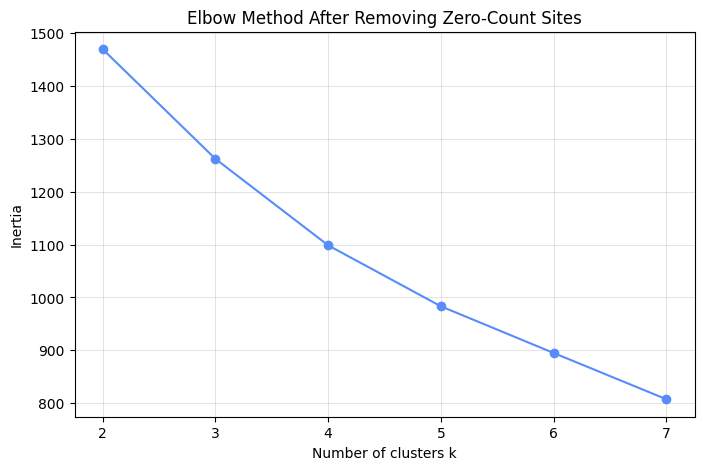

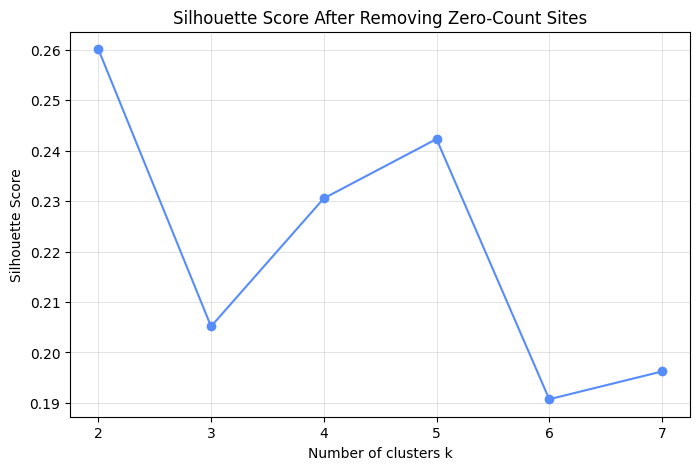

In [12]:
#choosing the optimum k by elbow and shilhouette ScribdDocument
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_active_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_active_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

In [13]:
#k means clustering (2024)

best_k = 2

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

# Raw KMeans labels: arbitrary 0/1 labels from algorithm
active_sites_df["cluster_raw"] = final_kmeans.fit_predict(X_active_scaled)

# Decide which raw cluster is high activity based on actual mean_count
cluster_mean_counts_2024 = (
    active_sites_df
    .groupby("cluster_raw")["mean_count"]
    .mean()
)

higher_cluster_2024 = cluster_mean_counts_2024.idxmax()
lower_cluster_2024 = cluster_mean_counts_2024.idxmin()

# Create mapping from raw KMeans labels to meaningful labels
raw_to_standard_cluster_2024 = {
    lower_cluster_2024: 0,
    higher_cluster_2024: 1
}

# Final standardized cluster:
# 0 = lower activity
# 1 = higher activity
active_sites_df["cluster"] = active_sites_df["cluster_raw"].map(
    raw_to_standard_cluster_2024
)

print("Raw cluster mean counts:")
print(cluster_mean_counts_2024)

print("\nRaw-to-standard cluster mapping:")
print(raw_to_standard_cluster_2024)

active_sites_df[["site_id", "cluster_raw", "cluster", "mean_count"]].head()

Raw cluster mean counts:
cluster_raw
0     4.929367
1    19.661645
Name: mean_count, dtype: float64

Raw-to-standard cluster mapping:
{np.int32(0): 0, np.int32(1): 1}


,site_id,cluster_raw,cluster,mean_count
0,1,0,0,8.394581
1,2,1,1,16.595856
2,3,1,1,15.415813
3,4,0,0,3.782445
4,5,0,0,3.940574


In [14]:
active_sites_df["cluster"].value_counts().sort_index()

cluster
0    82
1    54
Name: count, dtype: int64

In [15]:
cluster_summary = (
    active_sites_df
    .groupby("cluster")[clustering_features_clean]
    .mean()
    .round(2)
)

cluster_summary

,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,weekend_weekday_ratio,rush_regular_ratio,count_variability,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster,,,,,,,,,,,,,,,
0,4.93,1.13,182.45,9.52,5.43,3.66,8.52,0.71,1.73,2.14,0.62,0.62,0.0,2383.85,1102.23
1,19.66,9.44,569.69,29.97,21.38,15.32,34.67,0.74,1.77,1.68,2.89,3.11,0.2,1421.20,690.94


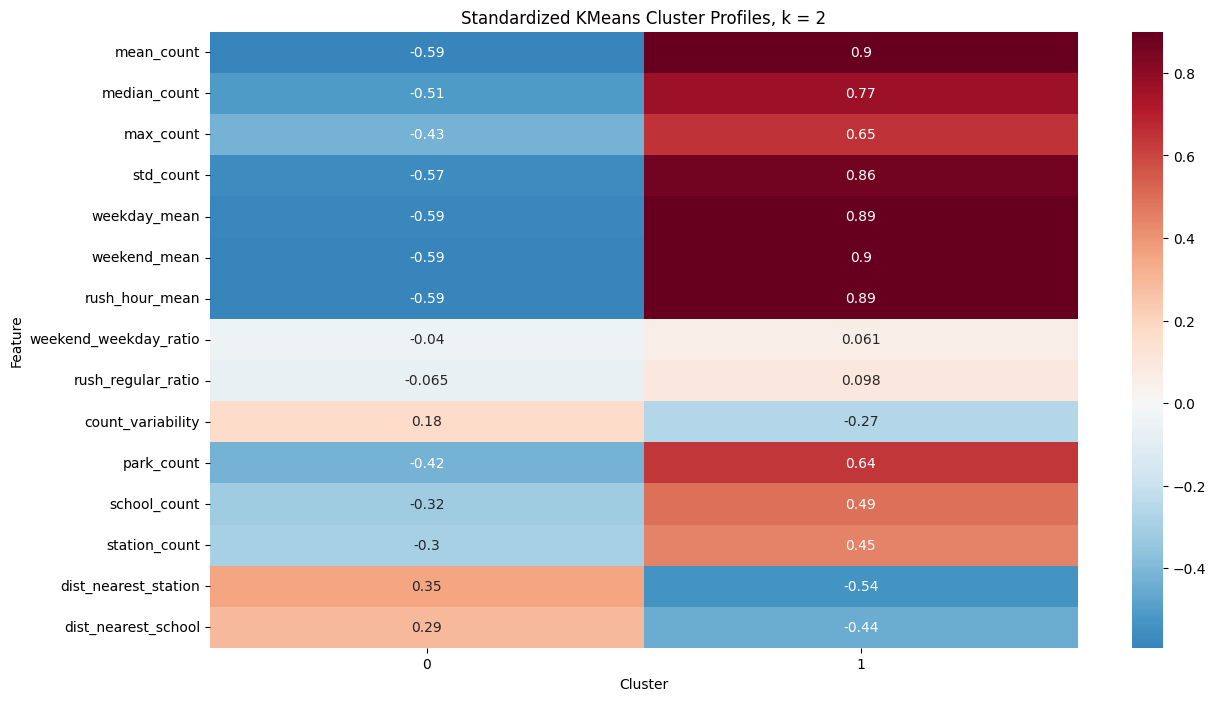

In [16]:

import seaborn as sns


scaled_df = pd.DataFrame(
    X_active_scaled,
    columns=clustering_features_clean
)

scaled_df["cluster"] = active_sites_df["cluster"].values

scaled_cluster_summary = scaled_df.groupby("cluster").mean()

plt.figure(figsize=(14, 8))
sns.heatmap(
    scaled_cluster_summary.T,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Standardized KMeans Cluster Profiles, k = 2")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.show()

This heatmap shows clustering of 2024d data- cluster 1 represents higher activity cycling sites - it has higher mean, median weekday, weekend and rush hour counts along with the more park, school and stations, in contrast the cluster0 represents lower activity sites and longer distances to nearby stations and schools, the weekend/weekday and rush/regular rations are close to zero meaning the main difference between the cluster would be overall activity level and infrastructure context not stronly different temporal patterns

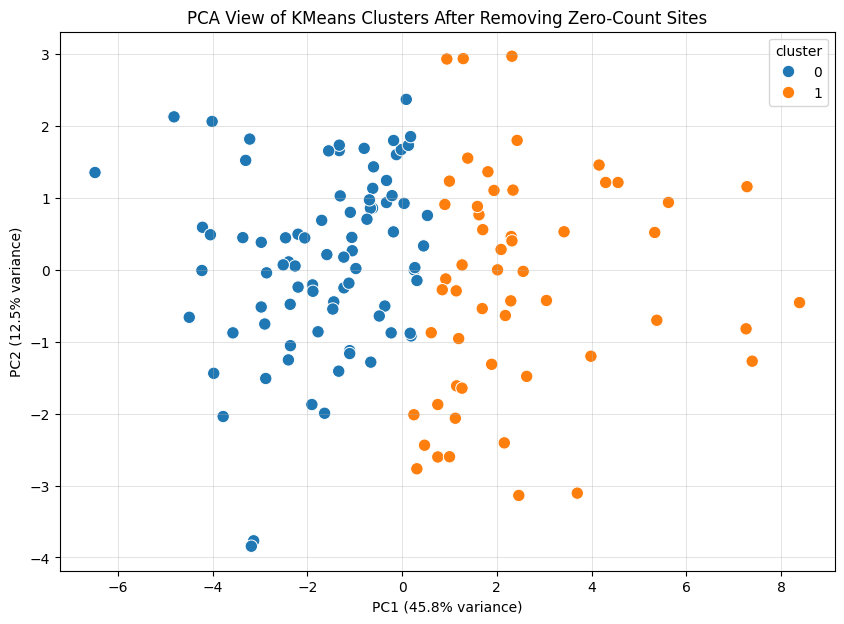

In [17]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=80
)

plt.title("PCA View of KMeans Clusters After Removing Zero-Count Sites")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.grid(True)
plt.show()

In [18]:
import plotly.express as px

if "lat" in active_sites_df.columns and "lon" in active_sites_df.columns:

    hover_cols = [
        col for col in [
            cluster_unit,
            "gemeente",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "park_count",
            "school_count",
            "station_count"
        ]
        if col in active_sites_df.columns
    ]

    fig = px.scatter_mapbox(
        active_sites_df,
        lat="lat",
        lon="lon",
        color=active_sites_df["cluster"].astype(str),
        size="mean_count",
        hover_data=hover_cols,
        zoom=7,
        mapbox_style="carto-positron",
        title="Spatial Distribution of 2024 Cycling Site Clusters"
    )

    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    fig.show()

else:
    print("Latitude/longitude columns not available for mapping.")

/var/folders/c8/m8g1yvks4vb884237m2b_pcr0000gn/T/ipykernel_28843/2777169980.py:20: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [19]:
cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_df["cluster_label"] = active_sites_df["cluster"].map(cluster_labels)

active_sites_df[
    [
        "site_id",
        "cluster_raw",
        "cluster",
        "cluster_label",
        "mean_count",
        "park_count",
        "school_count",
        "station_count"
    ]
].head()

,site_id,cluster_raw,cluster,cluster_label,mean_count,park_count,school_count,station_count
0,1,0,0,Lower-activity / peripheral sites,8.394581,0.0,0.0,0.0
1,2,1,1,Higher-activity / infrastructure-supported sites,16.595856,0.0,0.0,0.0
2,3,1,1,Higher-activity / infrastructure-supported sites,15.415813,0.0,0.0,0.0
3,4,0,0,Lower-activity / peripheral sites,3.782445,0.0,1.0,0.0
4,5,0,0,Lower-activity / peripheral sites,3.940574,0.0,1.0,0.0


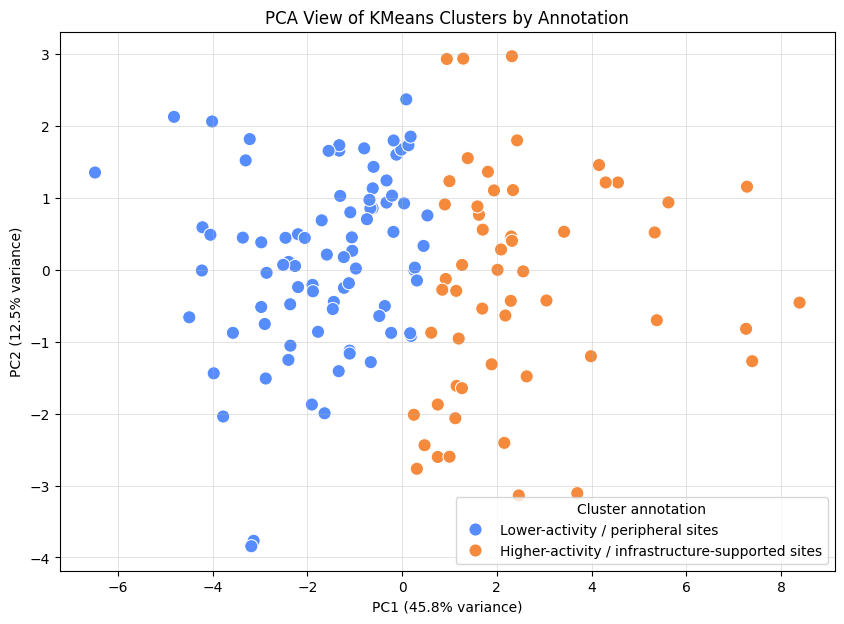

In [21]:

#pca visulisation

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster_label",
    s=90
)

plt.title("PCA View of KMeans Clusters by Annotation")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster annotation")
plt.grid(True)
plt.show()

In [22]:
cluster_info = active_sites_df[
    ["site_id", "cluster", "cluster_label"]
].copy()

df_clustered = df_2024.merge(
    cluster_info,
    on="site_id",
    how="inner"
)

df_clustered.shape

(2368048, 46)

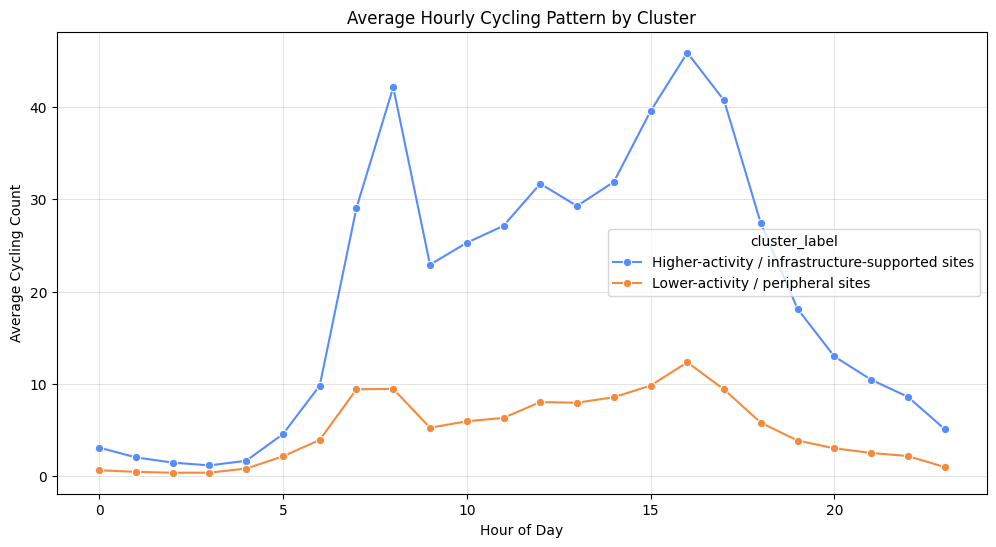

In [23]:
hourly_profile = (
    df_clustered
    .groupby(["cluster_label", "hour"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_profile,
    x="hour",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Average Hourly Cycling Pattern by Cluster")
plt.xlabel("Hour of Day")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

the figure shows that higher activity/infrastructure supported sites have much larger cycling counts throughout the day as compare to loweer activity sites, both clusters show clear commuter peaks in the morning around 7-8 and again in afternoon around 15-17 but the peak is much higher in higher activity sites.

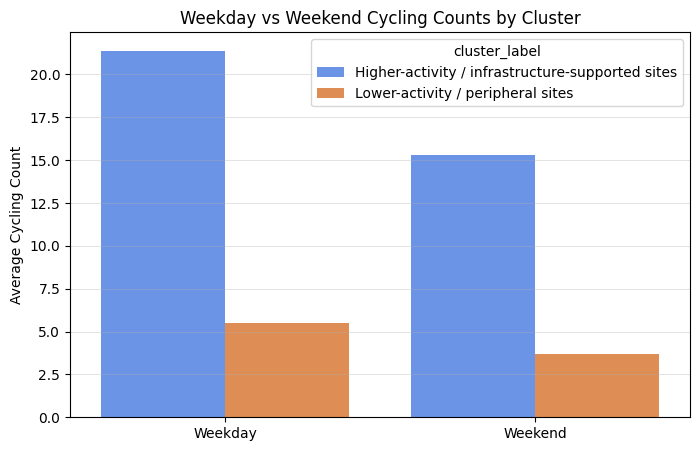

In [24]:
weekday_profile = (
    df_clustered
    .groupby(["cluster_label", "is_weekend_binary"])["count"]
    .mean()
    .reset_index()
)

weekday_profile["day_type"] = weekday_profile["is_weekend_binary"].map({
    0: "Weekday",
    1: "Weekend"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekday_profile,
    x="day_type",
    y="count",
    hue="cluster_label"
)

plt.title("Weekday vs Weekend Cycling Counts by Cluster")
plt.xlabel("")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

the figure compares the weekend and weekday cycling activity of two clusters and the higher activity sites have much higher average counts on both weekdays and weekends showing that these location consistently attract more cyclists. both cluster shows lower activity during weekends suggestinbg that cycling at these sites is partly linked to weekday commuting or routine travel patterns

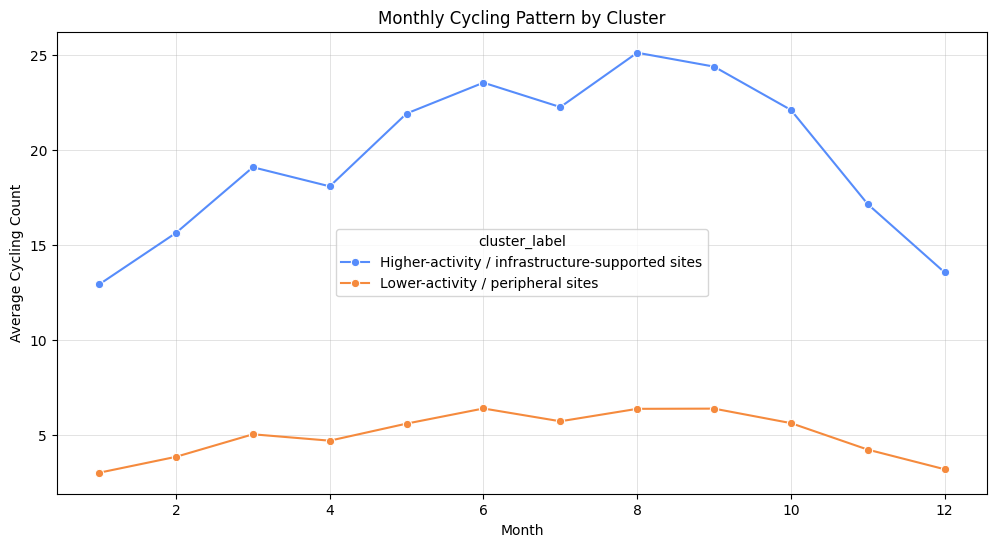

In [25]:
monthly_profile = (
    df_clustered
    .groupby(["cluster_label", "month"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profile,
    x="month",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Monthly Cycling Pattern by Cluster")
plt.xlabel("Month")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

the figure shows clear seasonal pattern in cycling activity for both clusters and cycling count increase from winter to summer with the highest activity during the august and september and decline again toward end of the year, the higher activity sites are remian consitently higher than the lower activity sites across all months and suggesting that the cluster difference is stable throughout a year.

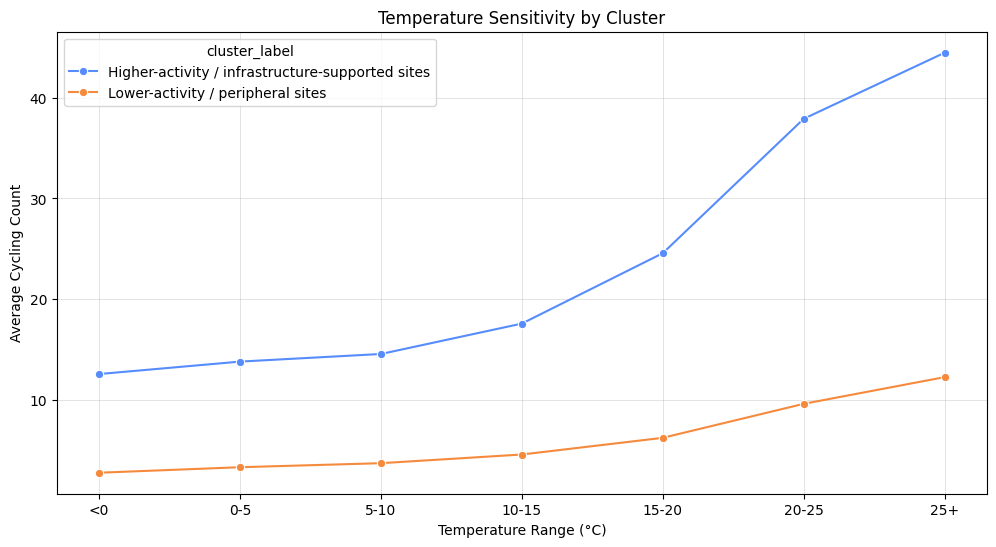

In [26]:
df_clustered["temperature_bin"] = pd.cut(
    df_clustered["temperature_2m"],
    bins=[-10, 0, 5, 10, 15, 20, 25, 35],
    labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", "25+"]
)

temp_profile = (
    df_clustered
    .groupby(["cluster_label", "temperature_bin"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=temp_profile,
    x="temperature_bin",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Temperature Sensitivity by Cluster")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

the figure shows that cycling activity increasees as temperature rises for both clusters and the higher activity sites are much more senstivie to warmer temperature with counts increasing sharply after 15°C and highest value above 25°C. the lower activity sites are show a gradual increase but the effect is much smaller . suggesting temp boost cycling everywhere but has a stronger impact at well connected high use locations.

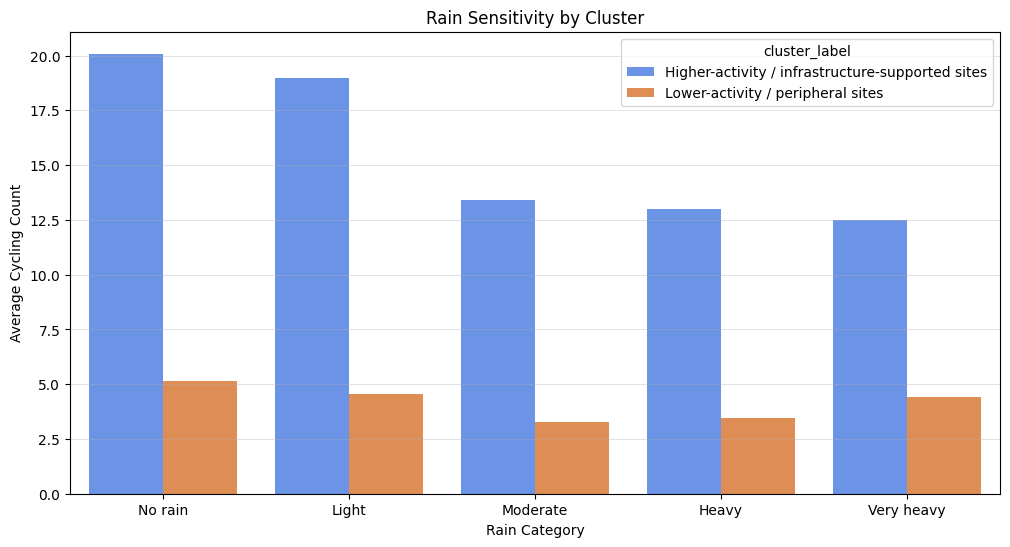

In [27]:
df_clustered["rain_category"] = pd.cut(
    df_clustered["precipitation"],
    bins=[-0.01, 0, 1, 3, 10, 100],
    labels=["No rain", "Light", "Moderate", "Heavy", "Very heavy"]
)

rain_profile = (
    df_clustered
    .groupby(["cluster_label", "rain_category"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rain_profile,
    x="rain_category",
    y="count",
    hue="cluster_label"
)

plt.title("Rain Sensitivity by Cluster")
plt.xlabel("Rain Category")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

the figure shows that cycling activity decreases as rain intensity increases especially for the higher activity. these sites have the higherst count during the no rain and light rain but activity drops clearly under the moderate to very heavy rain, the lower activity also show lower count during the rain but the chnage is smaller bcz their overall cycling activity is already low

In [28]:
representative_sites = (
    active_sites_df
    .sort_values(["cluster", "mean_count"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
)

representative_sites[
    ["site_id", "cluster_label", "mean_count", "weekday_mean", "weekend_mean",
     "rush_hour_mean", "park_count", "school_count", "station_count"]
]

,site_id,cluster_label,mean_count,weekday_mean,weekend_mean,rush_hour_mean,park_count,school_count,station_count
111,112,Lower-activity / peripheral sites,10.809995,13.083492,5.082532,14.800319,0.0,0.0,0.0
126,127,Lower-activity / peripheral sites,10.179133,12.434001,4.498598,14.717213,0.0,0.0,0.0
83,84,Lower-activity / peripheral sites,10.175603,11.485926,6.874599,19.875911,0.0,0.0,0.0
60,61,Lower-activity / peripheral sites,9.861965,11.200620,6.489583,21.951047,0.0,0.0,0.0
61,62,Lower-activity / peripheral sites,9.781364,11.131282,6.380609,18.612250,0.0,0.0,0.0
139,143,Higher-activity / infrastructure-supported sites,90.070014,99.965013,65.142228,160.357696,12.0,4.0,0.0
106,107,Higher-activity / infrastructure-supported sites,86.822291,95.233540,65.632412,159.028233,0.0,7.0,0.0
68,69,Higher-activity / infrastructure-supported sites,47.373008,54.816396,28.621394,90.230191,6.0,25.0,0.0
63,64,Higher-activity / infrastructure-supported sites,43.915699,40.938534,51.415865,60.178962,3.0,3.0,0.0
135,137,Higher-activity / infrastructure-supported sites,42.263604,46.215410,32.308093,72.055783,1.0,8.0,0.0


In [29]:
infra_summary = (
    active_sites_df
    .groupby("cluster_label")[
        ["park_count", "school_count", "station_count",
         "dist_nearest_station", "dist_nearest_school"]
    ]
    .mean()
    .round(2)
)

infra_summary

,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster_label,,,,,
Higher-activity / infrastructure-supported sites,2.89,3.11,0.2,1421.20,690.94
Lower-activity / peripheral sites,0.62,0.62,0.0,2383.85,1102.23


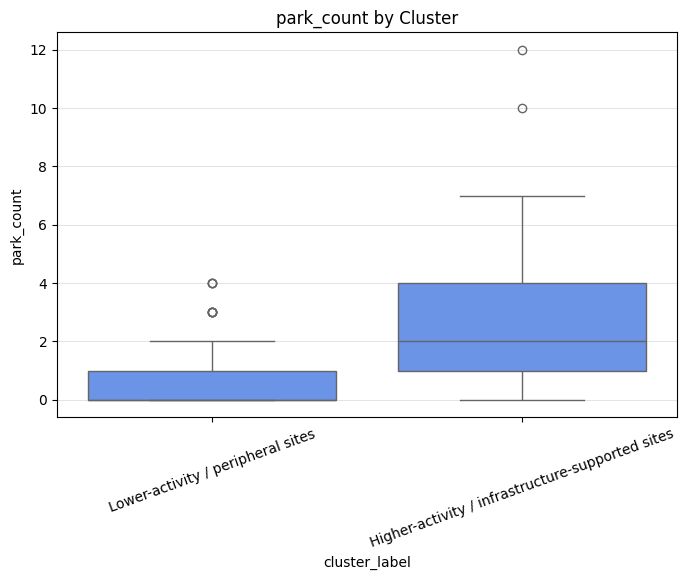

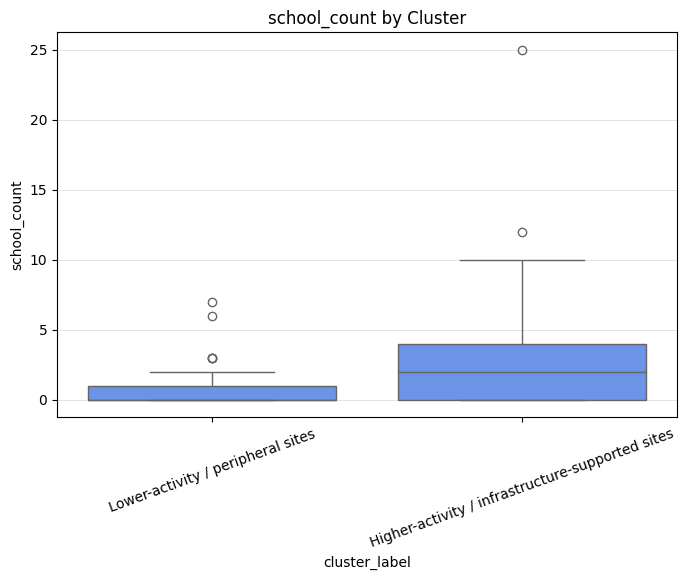

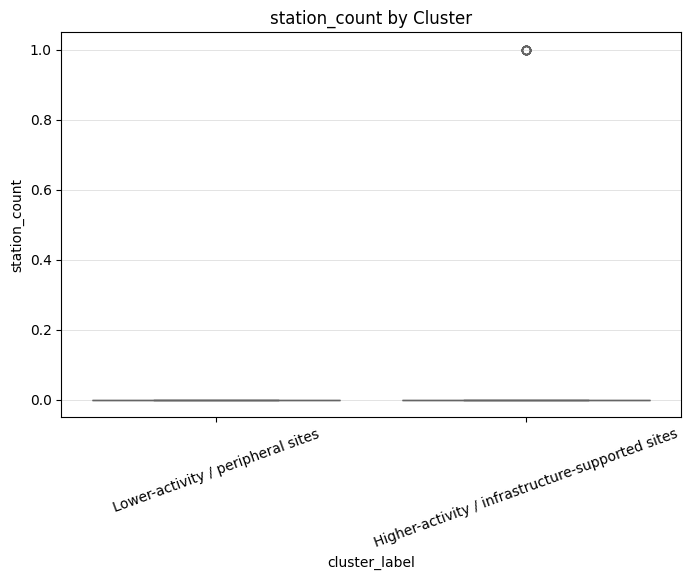

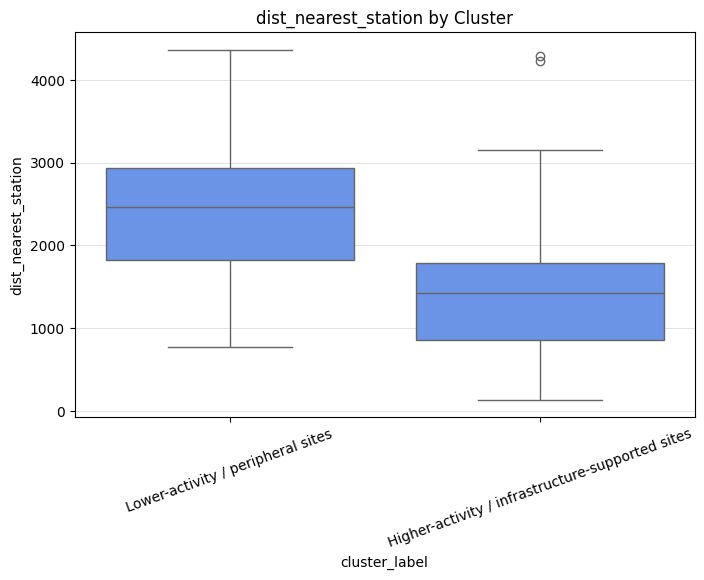

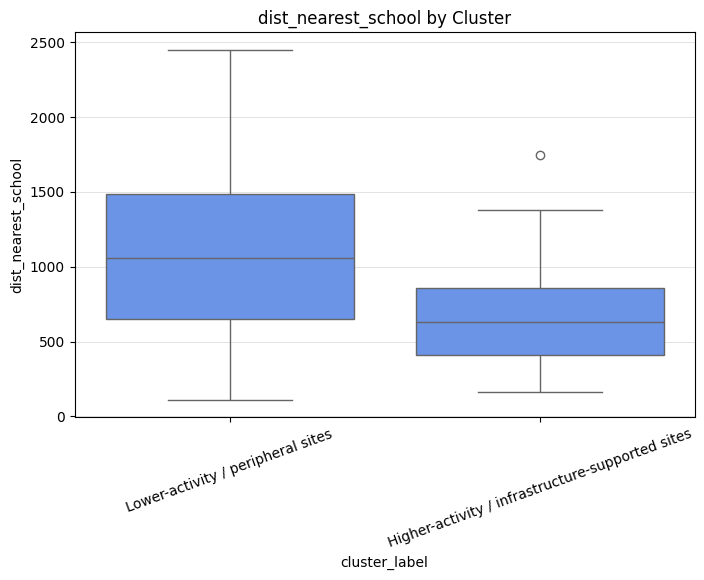

In [30]:
infra_features = [
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

for feature in infra_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=active_sites_df,
        x="cluster_label",
        y=feature
    )
    plt.title(f"{feature} by Cluster")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.show()

In [31]:
# save final 2024 KMeans model clearly
kmeans_2024 = final_kmeans

# save the raw-to-standard mapping from 2024
cluster_mapping_2024 = raw_to_standard_cluster_2024

# save final 2024 clustered site dataframe clearly
active_sites_2024 = active_sites_df.copy()

active_sites_2024["cluster_2024_raw"] = active_sites_2024["cluster_raw"]
active_sites_2024["cluster_2024"] = active_sites_2024["cluster"]
active_sites_2024["cluster_label_2024"] = active_sites_2024["cluster_label"]

active_sites_2024[
    [
        "site_id",
        "cluster_2024_raw",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ]
].head()

,site_id,cluster_2024_raw,cluster_2024,cluster_label_2024,mean_count,weekday_mean,weekend_mean,rush_hour_mean
0,1,0,0,Lower-activity / peripheral sites,8.394581,9.287691,6.144631,15.245902
1,2,1,1,Higher-activity / infrastructure-supported sites,16.595856,19.301924,9.778646,31.885018
2,3,1,1,Higher-activity / infrastructure-supported sites,15.415813,17.824268,9.348357,30.094490
3,4,0,0,Lower-activity / peripheral sites,3.782445,3.932252,3.405048,6.005464
4,5,0,0,Lower-activity / peripheral sites,3.940574,4.074109,3.604167,6.266166


In [32]:
print("2024 model clusters:", kmeans_2024.n_clusters)

active_sites_2024["cluster_label_2024"].value_counts()

2024 model clusters: 2


cluster_label_2024
Lower-activity / peripheral sites                   82
Higher-activity / infrastructure-supported sites    54
Name: count, dtype: int64

In [33]:
required_objects = [
    "active_sites_2024",
    "kmeans_2024",
    "imputer",
    "scaler",
    "clustering_features_clean",
    "count_like_features"
]

for obj in required_objects:
    print(obj, "exists" if obj in globals() else "MISSING")

active_sites_2024 exists
kmeans_2024 exists
imputer exists
scaler exists
clustering_features_clean exists
count_like_features exists


In [ ]:

import os

parquet_path = "/content/drive/MyDrive/Colab Notebooks/fietstellingen_clean.parquet"

print(os.path.exists(parquet_path))

In [ ]:
# columns needed for 2025 clustering
needed_cols = [
    "site_id",
    "start_time",
    "end_time",
    "count",
    "lat",
    "lon",
    "site_name",
    "municipality",
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "day_of_week",
    "is_weekend"
]

# first read only useful columns
df_all_small = pd.read_parquet(
    parquet_path,
    columns=needed_cols
)

print(df_all_small.shape)
df_all_small.head()

In [ ]:
df_2025 = df_all_small[df_all_small["year"].astype(int) == 2025].copy()

print("2025 shape:", df_2025.shape)
df_2025.head()

In [ ]:


enriched_path = "/content/drive/MyDrive/Colab Notebooks/enriched_sites.csv"

enriched_sites = pd.read_csv(enriched_path)

print(enriched_sites.shape)
print(enriched_sites.columns.tolist())
enriched_sites.head()

In [ ]:
enriched_sites_clean = enriched_sites.rename(columns={
    "site_ID": "site_id",
    "long": "site_lon_enriched",
    "lat": "site_lat_enriched",
    "gemeente": "municipality_enriched",
    "naam": "site_name_enriched"
})

df_2025["site_id"] = pd.to_numeric(df_2025["site_id"], errors="coerce")
enriched_sites_clean["site_id"] = pd.to_numeric(
    enriched_sites_clean["site_id"],
    errors="coerce"
)

enriched_keep_cols = [
    "site_id",
    "site_lon_enriched",
    "site_lat_enriched",
    "municipality_enriched",
    "site_name_enriched",
    "dist_nearest_station",
    "dist_nearest_school",
    "school_count",
    "station_count",
    "park_count"
]

enriched_sites_clean = enriched_sites_clean[
    [col for col in enriched_keep_cols if col in enriched_sites_clean.columns]
].drop_duplicates(subset=["site_id"])

enriched_sites_clean.head()

In [ ]:
cycling_sites_2025 = set(df_2025["site_id"].dropna().unique())
enriched_site_ids = set(enriched_sites_clean["site_id"].dropna().unique())

overlap = cycling_sites_2025.intersection(enriched_site_ids)

print("Unique 2025 cycling sites:", len(cycling_sites_2025))
print("Unique enriched sites:", len(enriched_site_ids))
print("Overlapping sites:", len(overlap))
print("Missing enriched sites:", len(cycling_sites_2025 - enriched_site_ids))

In [ ]:
df_2025_enriched = df_2025.merge(
    enriched_sites_clean,
    on="site_id",
    how="left"
)

print("Before merge:", df_2025.shape)
print("After merge:", df_2025_enriched.shape)

df_2025_enriched.head()

In [ ]:
df_2025_enriched.to_csv("2025_site_count.csv", index=False)

In [ ]:
enriched_features = [
    "dist_nearest_station",
    "dist_nearest_school",
    "school_count",
    "station_count",
    "park_count"
]

df_2025_enriched[enriched_features].isna().mean().sort_values()

In [ ]:
df_2025_enriched["count"] = pd.to_numeric(
    df_2025_enriched["count"],
    errors="coerce"
)

df_2025_enriched["hour"] = pd.to_numeric(
    df_2025_enriched["hour"],
    errors="coerce"
)

# Weekend flag
if "is_weekend" in df_2025_enriched.columns:
    df_2025_enriched["is_weekend_binary"] = (
        df_2025_enriched["is_weekend"].astype(int)
    )
else:
    df_2025_enriched["date_dt"] = pd.to_datetime(
        df_2025_enriched[["year", "month", "day"]],
        errors="coerce"
    )

    df_2025_enriched["is_weekend_binary"] = (
        df_2025_enriched["date_dt"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

# Rush hour flag
df_2025_enriched["is_rush_hour"] = (
    df_2025_enriched["hour"]
    .isin([7, 8, 9, 16, 17, 18])
    .astype(int)
)

# Helper count columns
df_2025_enriched["weekday_count"] = np.where(
    df_2025_enriched["is_weekend_binary"] == 0,
    df_2025_enriched["count"],
    np.nan
)

df_2025_enriched["weekend_count"] = np.where(
    df_2025_enriched["is_weekend_binary"] == 1,
    df_2025_enriched["count"],
    np.nan
)

df_2025_enriched["rush_hour_count"] = np.where(
    df_2025_enriched["is_rush_hour"] == 1,
    df_2025_enriched["count"],
    np.nan
)

In [ ]:
df_2025_enriched["lat_final"] = df_2025_enriched["lat"].fillna(
    df_2025_enriched["site_lat_enriched"]
)

df_2025_enriched["lon_final"] = df_2025_enriched["lon"].fillna(
    df_2025_enriched["site_lon_enriched"]
)

In [ ]:
site_cluster_2025 = (
    df_2025_enriched
    .groupby("site_id")
    .agg(
        mean_count=("count", "mean"),
        median_count=("count", "median"),
        max_count=("count", "max"),
        std_count=("count", "std"),

        weekday_mean=("weekday_count", "mean"),
        weekend_mean=("weekend_count", "mean"),
        rush_hour_mean=("rush_hour_count", "mean"),

        park_count=("park_count", "mean"),
        school_count=("school_count", "mean"),
        station_count=("station_count", "mean"),
        dist_nearest_station=("dist_nearest_station", "mean"),
        dist_nearest_school=("dist_nearest_school", "mean"),

        lat=("lat_final", "mean"),
        lon=("lon_final", "mean"),
        municipality=("municipality", "first"),
        municipality_enriched=("municipality_enriched", "first"),
        site_name=("site_name", "first"),
        site_name_enriched=("site_name_enriched", "first")
    )
    .reset_index()
)

site_cluster_2025.head()

In [ ]:
active_sites_2025 = site_cluster_2025[
    (site_cluster_2025["mean_count"] > 0) &
    (site_cluster_2025["max_count"] > 0)
].copy()

print("2025 before filtering:", site_cluster_2025.shape)
print("2025 after filtering:", active_sites_2025.shape)

In [ ]:
required_objects = [
    "kmeans_2024",
    "imputer",
    "scaler",
    "clustering_features_clean",
    "count_like_features"
]

for obj in required_objects:
    print(obj, "exists" if obj in globals() else "MISSING")

In [ ]:
# Create ratio features for 2025 site-level data
site_cluster_2025["weekend_weekday_ratio"] = (
    site_cluster_2025["weekend_mean"] /
    (site_cluster_2025["weekday_mean"] + 1e-6)
)

site_cluster_2025["rush_regular_ratio"] = (
    site_cluster_2025["rush_hour_mean"] /
    (site_cluster_2025["mean_count"] + 1e-6)
)

site_cluster_2025["count_variability"] = (
    site_cluster_2025["std_count"] /
    (site_cluster_2025["mean_count"] + 1e-6)
)

site_cluster_2025 = site_cluster_2025.replace([np.inf, -np.inf], np.nan)

site_cluster_2025[
    ["site_id", "weekend_weekday_ratio", "rush_regular_ratio", "count_variability"]
].head()

In [ ]:
active_sites_2025 = site_cluster_2025[
    (site_cluster_2025["mean_count"] > 0) &
    (site_cluster_2025["max_count"] > 0)
].copy()

print("2025 before filtering:", site_cluster_2025.shape)
print("2025 after filtering:", active_sites_2025.shape)

In [ ]:
missing_features = [
    col for col in clustering_features_clean
    if col not in active_sites_2025.columns
]

print("Missing features in 2025:", missing_features)

In [ ]:
X_2025 = active_sites_2025[clustering_features_clean].copy()
X_2025 = X_2025.replace([np.inf, -np.inf], np.nan)

X_2025_transformed = X_2025.copy()

for col in count_like_features:
    if col in X_2025_transformed.columns:
        X_2025_transformed[col] = np.log1p(X_2025_transformed[col])

X_2025_imputed = imputer.transform(X_2025_transformed)
X_2025_scaled = scaler.transform(X_2025_imputed)

# Predict raw 2025 cluster using the 2024 KMeans model
active_sites_2025["cluster_2025_raw"] = kmeans_2024.predict(X_2025_scaled)

# Convert raw 2025 prediction into the same meaningful 0/1 labels from 2024
active_sites_2025["cluster_2025"] = active_sites_2025[
    "cluster_2025_raw"
].map(raw_to_standard_cluster_2024)

cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_2025["cluster_label_2025"] = (
    active_sites_2025["cluster_2025"].map(cluster_labels)
)

active_sites_2025[
    [
        "site_id",
        "cluster_2025_raw",
        "cluster_2025",
        "cluster_label_2025",
        "mean_count"
    ]
].head()

In [ ]:
active_sites_2024["cluster_label_2024"].value_counts()

In [ ]:
common_sites = set(active_sites_2024["site_id"]).intersection(
    set(active_sites_2025["site_id"])
)

print("2024 active sites:", active_sites_2024["site_id"].nunique())
print("2025 active sites:", active_sites_2025["site_id"].nunique())
print("Common sites:", len(common_sites))

In [ ]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "lat",
            "lon",
            "municipality",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

print(comparison_df.shape)
comparison_df.head()

In [ ]:
transition_matrix = pd.crosstab(
    comparison_df["cluster_label_2024"],
    comparison_df["cluster_label_2025"],
    margins=True
)

transition_matrix

In [ ]:
df_2025["month"].value_counts().sort_index()

In [ ]:
df_2025.groupby("month").size().reset_index(name="n_records")

In [ ]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean",
        "park_count",
        "school_count",
        "station_count",
        "dist_nearest_station",
        "dist_nearest_school"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "park_count",
            "school_count",
            "station_count",
            "dist_nearest_station",
            "dist_nearest_school",
            "lat",
            "lon",
            "municipality",
            "municipality_enriched",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

print(comparison_df.shape)
comparison_df.head()

In [ ]:
def classify_shift(row):
    if row["cluster_2024"] == 0 and row["cluster_2025"] == 0:
        return "Stable lower-activity"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 1:
        return "Stable higher-activity"
    elif row["cluster_2024"] == 0 and row["cluster_2025"] == 1:
        return "Shifted upward: lower to higher"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 0:
        return "Shifted downward: higher to lower"
    else:
        return "Other"

comparison_df["shift_type"] = comparison_df.apply(classify_shift, axis=1)

comparison_df["shift_type"].value_counts()

In [ ]:
transition_matrix = pd.crosstab(
    comparison_df["cluster_label_2024"],
    comparison_df["cluster_label_2025"],
    margins=True
)

transition_matrix

In [ ]:
comparison_df["delta_mean_count"] = (
    comparison_df["mean_count_2025"] - comparison_df["mean_count_2024"]
)

comparison_df["percent_change_mean_count"] = (
    comparison_df["delta_mean_count"] /
    (comparison_df["mean_count_2024"] + 1e-6)
) * 100

comparison_df[
    [
        "site_id",
        "shift_type",
        "mean_count_2024",
        "mean_count_2025",
        "delta_mean_count",
        "percent_change_mean_count"
    ]
].head()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=comparison_df,
    y="shift_type",
    order=comparison_df["shift_type"].value_counts().index
)

plt.title("Cycling Site Behaviour Shifts from 2024 to 2025")
plt.xlabel("Number of sites")
plt.ylabel("")
plt.grid(axis="x")
plt.show()

the fig shows how cycling sites changed their cluster behaviour from 2024 t0 2025 and most sites remained stable lower activity sitres while smaller group shifted downward from higher activity to lower activity, suggested reduced cycling intensity or weaker similarity to the high activity profile in 2025 and only few sites remianed stable higher activity.

In [ ]:
comparison_df["shift_type"].value_counts()

#Separate 2025 clustering

In [ ]:
X_2025_sep = active_sites_2025[clustering_features_clean].copy()
X_2025_sep = X_2025_sep.replace([np.inf, -np.inf], np.nan)

X_2025_sep_transformed = X_2025_sep.copy()

for col in count_like_features:
    if col in X_2025_sep_transformed.columns:
        X_2025_sep_transformed[col] = np.log1p(X_2025_sep_transformed[col])

imputer_2025 = SimpleImputer(strategy="median")
X_2025_sep_imputed = imputer_2025.fit_transform(X_2025_sep_transformed)

scaler_2025 = StandardScaler()
X_2025_sep_scaled = scaler_2025.fit_transform(X_2025_sep_imputed)

In [ ]:
inertias_2025 = []
silhouette_scores_2025 = []

K_range = range(2, 8)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_2025_sep_scaled)

    inertias_2025.append(km.inertia_)
    silhouette_scores_2025.append(silhouette_score(X_2025_sep_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias_2025, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for 2025 Separate Clustering")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_2025, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for 2025 Separate Clustering")
plt.grid(True)
plt.show()

In [ ]:
kmeans_2025_separate = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

active_sites_2025["cluster_2025_separate_raw"] = kmeans_2025_separate.fit_predict(
    X_2025_sep_scaled
)

active_sites_2025["cluster_2025_separate_raw"].value_counts().sort_index()

In [ ]:
cluster_mean_counts_2025 = (
    active_sites_2025
    .groupby("cluster_2025_separate_raw")["mean_count"]
    .mean()
)

higher_cluster_2025 = cluster_mean_counts_2025.idxmax()
lower_cluster_2025 = cluster_mean_counts_2025.idxmin()

raw_to_standard_cluster_2025 = {
    lower_cluster_2025: 0,
    higher_cluster_2025: 1
}

active_sites_2025["cluster_2025_separate"] = active_sites_2025[
    "cluster_2025_separate_raw"
].map(raw_to_standard_cluster_2025)

active_sites_2025["cluster_label_2025_separate"] = active_sites_2025[
    "cluster_2025_separate"
].map(cluster_labels)

print("2025 separate raw cluster mean counts:")
print(cluster_mean_counts_2025)

print("\n2025 separate raw-to-standard mapping:")
print(raw_to_standard_cluster_2025)

In [ ]:
pd.crosstab(
    active_sites_2025["cluster_label_2025"],
    active_sites_2025["cluster_label_2025_separate"],
    margins=True
)

In [ ]:
scaled_2025_sep_df = pd.DataFrame(
    X_2025_sep_scaled,
    columns=clustering_features_clean
)

scaled_2025_sep_df["cluster"] = active_sites_2025["cluster_2025_separate"].values

scaled_2025_sep_summary = scaled_2025_sep_df.groupby("cluster").mean()

plt.figure(figsize=(14, 8))
sns.heatmap(
    scaled_2025_sep_summary.T,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Standardized Cluster Profiles for 2025 Separate KMeans")
plt.xlabel("2025 Separate Cluster")
plt.ylabel("Feature")
plt.show()

This heatmap shows clustering of 2025 data- cluster 1 represents higher activity cycling sites - it has higher mean, median weekday, weekend and rush hour counts along with the more park, school and stations, in contrast the cluster0 represents lower activity sites and longer distances to nearby stations and schools, the weekend/weekday and rush/regular rations are close to zero meaning the main difference between the cluster would be overall activity level and infrastructure context not stronly different temporal patterns

In [ ]:
ari = adjusted_rand_score(
    active_sites_2025["cluster_2025"],
    active_sites_2025["cluster_2025_separate"]
)

nmi = normalized_mutual_info_score(
    active_sites_2025["cluster_2025"],
    active_sites_2025["cluster_2025_separate"]
)

print("Adjusted Rand Index:", round(ari, 3))
print("Normalized Mutual Information:", round(nmi, 3))

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# fit PCA on 2024 scaled features
pca_2024_space = PCA(n_components=2, random_state=42)
pca_2024_space.fit(X_active_scaled)

# project 2025 into the 2024 PCA space
pca_2025_result = pca_2024_space.transform(X_2025_scaled)

active_sites_2025["PC1_2025"] = pca_2025_result[:, 0]
active_sites_2025["PC2_2025"] = pca_2025_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=active_sites_2025,
    x="PC1_2025",
    y="PC2_2025",
    hue="cluster_label_2025",
    s=90
)

plt.title("PCA Projection of 2025 Sites Using 2024 Baseline Space")
plt.xlabel(f"PC1 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="2025 predicted cluster")
plt.grid(True)
plt.show()

the above pca plot projects the 2025 sites into 2024 baseline feature space so it shows 2025 sites relate to clustering learneed from 2024. most 2025 sites are classified as lower activity sites are concentrated to left site of pc1 while the higher activity sites appear clearly separated toward the right side, this suggest that pc1 mainly captures the difference between low and high activity supporting cycling profiles.

In [ ]:
# 2024 PCA coordinates
pca_2024_result = pca_2024_space.transform(X_active_scaled)

active_sites_2024["PC1"] = pca_2024_result[:, 0]
active_sites_2024["PC2"] = pca_2024_result[:, 1]
active_sites_2024["year_label"] = "2024"
active_sites_2024["cluster_label_common"] = active_sites_2024["cluster_label_2024"]

# 2025 PCA coordinates
active_sites_2025["PC1"] = pca_2025_result[:, 0]
active_sites_2025["PC2"] = pca_2025_result[:, 1]
active_sites_2025["year_label"] = "2025"
active_sites_2025["cluster_label_common"] = active_sites_2025["cluster_label_2025"]

pca_compare_df = pd.concat(
    [
        active_sites_2024[["site_id", "PC1", "PC2", "year_label", "cluster_label_common"]],
        active_sites_2025[["site_id", "PC1", "PC2", "year_label", "cluster_label_common"]]
    ],
    ignore_index=True
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_compare_df,
    x="PC1",
    y="PC2",
    hue="cluster_label_common",
    style="year_label",
    s=90,
    alpha=0.8
)

plt.title("PCA Comparison of Cycling Site Behaviour: 2024 vs 2025")
plt.xlabel(f"PC1 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster / Year")
plt.grid(True)
plt.show()

this pca plot compares cycling site behaviour in 2024 and 2025 using the 2024 space , the lower activity sites are mainly located on the left site of pc1 while higher activity supported sites are seperated toward the right showing the pc1 captures the main difference between low and high activity profiles. the overlap between 2024 circles and 2025 crosses suggest that the overall structure is similar across years and but some 2025 sites shift position, indicating changes in site behaviour over time

In [ ]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "lat",
            "lon",
            "municipality",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

def classify_shift(row):
    if row["cluster_2024"] == 0 and row["cluster_2025"] == 0:
        return "Stable lower-activity"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 1:
        return "Stable higher-activity"
    elif row["cluster_2024"] == 0 and row["cluster_2025"] == 1:
        return "Shifted upward: lower to higher"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 0:
        return "Shifted downward: higher to lower"
    else:
        return "Other"

comparison_df["shift_type"] = comparison_df.apply(classify_shift, axis=1)

comparison_df["delta_mean_count"] = (
    comparison_df["mean_count_2025"] - comparison_df["mean_count_2024"]
)

comparison_df["percent_change_mean_count"] = (
    comparison_df["delta_mean_count"] /
    (comparison_df["mean_count_2024"] + 1e-6)
) * 100

comparison_df["shift_type"].value_counts()

In [ ]:
import plotly.express as px

fig = px.scatter_mapbox(
    comparison_df,
    lat="lat",
    lon="lon",
    color="shift_type",
    size="mean_count_2025",
    hover_name="site_id",
    hover_data=[
        "site_name",
        "municipality",
        "cluster_label_2024",
        "cluster_label_2025",
        "mean_count_2024",
        "mean_count_2025",
        "delta_mean_count",
        "percent_change_mean_count"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="Spatial Shift in Cycling Site Behaviour: 2024 to 2025"
)

fig.update_layout(
    legend_title_text="Shift type",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig.show()

In [ ]:
fig_2024 = px.scatter_mapbox(
    active_sites_2024,
    lat="lat",
    lon="lon",
    color="cluster_label_2024",
    size="mean_count",
    hover_name="site_id",
    hover_data=[
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="2024 Cycling Site Clusters"
)

fig_2024.update_layout(
    legend_title_text="2024 cluster",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig_2024.show()

In [ ]:
fig_2025 = px.scatter_mapbox(
    active_sites_2025,
    lat="lat",
    lon="lon",
    color="cluster_label_2025",
    size="mean_count",
    hover_name="site_id",
    hover_data=[
        "cluster_label_2025",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="2025 Cycling Site Clusters Predicted from 2024 Model"
)

fig_2025.update_layout(
    legend_title_text="2025 predicted cluster",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig_2025.show()

In [ ]:
df_2025["month"].value_counts().sort_index()

In [ ]:
df_2024["month"].value_counts().sort_index()

In [ ]:
infra_cols = ["school_count", "park_count", "station_count"]

for col in infra_cols:
    if col in active_sites_2024.columns:
        zero_pct_2024 = (active_sites_2024[col] == 0).mean() * 100
        print(f"2024 {col}: {zero_pct_2024:.1f}% zeros")

print("\n--- 2025 ---")

for col in infra_cols:
    if col in active_sites_2025.columns:
        zero_pct_2025 = (active_sites_2025[col] == 0).mean() * 100
        print(f"2025 {col}: {zero_pct_2025:.1f}% zeros")

In [ ]:
active_sites_2024.groupby("cluster_label_2024")[
    ["school_count", "park_count", "station_count"]
].mean().round(2)

In [ ]:
active_sites_2025.groupby("cluster_label_2025")[
    ["school_count", "park_count", "station_count"]
].mean().round(2)